STEP 1 — Setup

In [1]:
!pip install -U pybaseball pandas

In [2]:
!pip install pybaseball pandas scikit-learn matplotlib seaborn


STEP 2 — Pull Statcast Data

In [29]:
from pybaseball import statcast
import pandas as pd

# Pull one season (try 2025)
data = statcast(start_dt="2025-04-01", end_dt="2025-10-01")

data.head()

This is a large query, it may take a moment to complete


/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
100%|██████████| 184/184 [00:25<00:00,  7.22it/s]


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
351,FF,2025-10-01,96.7,-2.27,5.8,"Smith, Cade",693307,671922,field_out,hit_into_play,...,1,1.04,1.03,1.03,40.4,-0.158216,30.463581,33.767846,36.037304,17.796143
360,FF,2025-10-01,96.3,-2.5,5.7,"Smith, Cade",693307,671922,NaN,swinging_strike,...,1,1.43,0.81,0.81,38.3,-7.785537,33.800045,37.751147,31.781746,12.476826
366,FF,2025-10-01,96.8,-2.51,5.65,"Smith, Cade",693307,671922,NaN,foul,...,1,1.32,0.56,0.56,36.6,7.256222,2.432506,43.471206,32.422763,27.80322
376,FF,2025-10-01,97.5,-2.42,5.72,"Smith, Cade",693307,671922,NaN,ball,...,1,1.25,0.73,0.73,37.3,<NA>,<NA>,<NA>,<NA>,<NA>
395,FF,2025-10-01,96.6,-2.47,5.66,"Smith, Cade",672761,671922,fielders_choice,hit_into_play,...,1,1.42,0.52,-0.52,36.1,-0.840287,7.724722,26.84735,27.45417,17.257405


In [30]:
print(data.shape)
print(len(data))

(695082, 118)
695082


Step 3 -
Filter for Relevant Plays: Balls in play Outfield plays Center field? (approximate)
Create Target Variable: Was it caught?

In [31]:
# Keep only balls in play
df = data[data['type'] == 'X'].copy()

# Keep airborne contact only
df = df[df['bb_type'].isin(['fly_ball', 'line_drive'])].copy()

# Drop rows missing key fields
df = df.dropna(subset=['launch_speed', 'launch_angle', 'hc_x', 'hc_y', 'events'])

# Target: whether the play resulted in an out
out_events = ['field_out', 'sac_fly', 'sac_fly_double_play', 'double_play']
df['is_out'] = df['events'].isin(out_events).astype(int)

print(df['events'].value_counts().head(15))
print(df['is_out'].value_counts())
print(df.shape)

events
field_out              33585
single                 13877
double                  6458
home_run                5461
sac_fly                 1251
triple                   554
double_play              307
field_error               95
force_out                 36
sac_fly_double_play       14
triple_play                2
fielders_choice            1
fielders_choice_out        1
Name: count, dtype: int64
is_out
1    35157
0    26485
Name: count, dtype: int64
(61642, 119)


Step 4 — Approximate center field opportunities using spray location

In [32]:
# Approximate center field zone using Statcast hit coordinates
cf_df = df[
    (df['hc_x'] > 100) & (df['hc_x'] < 150) &
    (df['hc_y'] > 140)
].copy()

print(cf_df.shape)
print(cf_df['is_out'].value_counts())
print("Unique CF IDs:", cf_df['fielder_8'].nunique())

(1484, 119)
is_out
1    1334
0     150
Name: count, dtype: int64
Unique CF IDs: 129


Step 4 - Feature Engineering

In [33]:
# Approximate distance from home plate as a difficulty proxy
cf_df['distance'] = ((cf_df['hc_x'] - 125)**2 + (cf_df['hc_y'] - 200)**2)**0.5

features = ['launch_speed', 'launch_angle', 'distance']

X = cf_df[features]
y = cf_df['is_out']

print(y.value_counts())
print(X.head())

is_out
1    1334
0     150
Name: count, dtype: int64
      launch_speed  launch_angle   distance
754           57.8            23   54.15578
441          105.1             6  57.504122
716           44.6            23  36.510761
774          107.3             5  44.928755
2315          68.9            13   54.06472


Step 5 - Train Model (logistic regression)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Score all plays for later aggregation
cf_df['catch_prob'] = model.predict_proba(X)[:, 1]

5A

In [35]:
# Quick model evaluation
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_pred_prob), 3))

Accuracy: 0.899
ROC AUC: 0.73


In [36]:
print(cf_df[['fielder_7', 'fielder_8', 'fielder_9']].head())
print("Unique CF IDs:", cf_df['fielder_8'].nunique())
print(cf_df['fielder_8'].value_counts().head(20))

      fielder_7  fielder_8  fielder_9
754      571771     681909     681624
441      668715     670770     669720
716      680757     690984     671286
774      664023     691718     673548
2315     687637     681297     641933
Unique CF IDs: 129
fielder_8
686668    59
670770    53
664728    50
671739    48
808982    47
678882    45
665833    43
691718    42
687363    42
663757    41
677594    41
673357    41
682657    34
677950    34
662139    30
656775    30
681624    27
621439    26
621438    26
696285    25
Name: count, dtype: Int64


STEP 6 — Player-Level Aggregation

In [37]:
player_stats = cf_df.groupby('fielder_8').agg(
    actual_outs=('is_out', 'sum'),
    expected_outs=('catch_prob', 'sum'),
    opportunities=('is_out', 'count')
).reset_index()

player_stats['OAE'] = player_stats['actual_outs'] - player_stats['expected_outs']

#player_stats = player_stats[player_stats['opportunities'] >= 20].copy() # removing because filter too strong at 20
player_stats = player_stats[player_stats['opportunities'] >= 5].copy()

player_stats = player_stats.dropna(subset=['fielder_8']).copy()
player_stats['player_id'] = player_stats['fielder_8'].astype(int)

In [38]:
print("Rows in player_stats before opportunity filter:", len(player_stats))
print(player_stats[['fielder_8', 'actual_outs', 'expected_outs', 'opportunities', 'OAE']].sort_values('opportunities', ascending=False).head(20))
print("Players with >=20 opportunities:", (player_stats['opportunities'] >= 20).sum())

Rows in player_stats before opportunity filter: 67
     fielder_8  actual_outs  expected_outs  opportunities       OAE
108     686668           52      52.730806             59 -0.730806
63      670770           48      47.528193             53  0.471807
35      664728           46      45.395503             50  0.604497
66      671739           44      42.509295             48  1.490705
128     808982           42      42.389435             47 -0.389435
86      678882           40      41.018033             45 -1.018033
40      665833           39      39.052930             43 -0.052930
117     691718           39      38.048419             42  0.951581
109     687363           39      37.292168             42  1.707832
72      673357           36      37.042502             41 -1.042502
80      677594           38      37.014329             41  0.985671
28      663757           38      37.964912             41  0.035088
100     682657           32      31.629357             34  0.3706

In [39]:
print(player_stats[['player_id', 'opportunities']].sort_values('opportunities', ascending=False).head(20))

     player_id  opportunities
108     686668             59
63      670770             53
35      664728             50
66      671739             48
128     808982             47
86      678882             45
40      665833             43
117     691718             42
109     687363             42
72      673357             41
80      677594             41
28      663757             41
100     682657             34
82      677950             34
24      662139             30
19      656775             30
95      681624             27
6       621438             26
7       621439             26
123     696285             25


STEP 7 — Add Player Names

In [47]:
from pybaseball import playerid_reverse_lookup, fielding_stats

# Match to Statcast season pulled above
season = 2025

# Drop columns that may already exist from prior reruns
cols_to_drop = [
    'key_mlbam', 'name_first', 'name_last', 'name',
    'name_clean', 'Name', 'Pos', 'Inn'
]
player_stats = player_stats.drop(columns=cols_to_drop, errors='ignore').copy()

# Reverse lookup MLBAM ids to player names
player_ids = player_stats['player_id'].dropna().astype(int).unique()
names = playerid_reverse_lookup(player_ids, key_type='mlbam')

player_stats = player_stats.merge(
    names[['key_mlbam', 'name_first', 'name_last']],
    left_on='player_id',
    right_on='key_mlbam',
    how='left'
)

player_stats['name'] = (
    player_stats['name_first'].fillna('Unknown') + ' ' +
    player_stats['name_last'].fillna('')
).str.strip()

# Pull season-level fielding data for the same season
fielding = fielding_stats(season)

print("Fielding columns:", fielding.columns.tolist())

# Filter to players listed as center fielders
cf_fielders = fielding[fielding['Pos'] == 'CF'].copy()

# Optional innings filter if available
if 'Inn' in cf_fielders.columns:
    cf_fielders = cf_fielders[cf_fielders['Inn'] >= 100].copy()

# Normalize names for reliable join
player_stats['name_clean'] = player_stats['name'].str.lower().str.strip()
cf_fielders['name_clean'] = cf_fielders['Name'].str.lower().str.strip()

# Keep only players who were CFs
player_stats = player_stats.merge(
    cf_fielders[['name_clean', 'Name', 'Pos'] + (['Inn'] if 'Inn' in cf_fielders.columns else [])],
    on='name_clean',
    how='inner'
)

# Clean up and sort
player_stats = player_stats.sort_values('OAE', ascending=False).reset_index(drop=True)

print(player_stats[['name', 'actual_outs', 'expected_outs', 'opportunities', 'OAE']].head(20))
print("Number of CFs after season-level filter:", len(player_stats))

Fielding columns: ['IDfg', 'Season', 'Name', 'Team', 'Pos', 'G', 'GS', 'Inn', 'PO', 'A', 'E', 'FE', 'TE', 'DP', 'DPS', 'DPT', 'DPF', 'Scp', 'SB', 'CS', 'PB', 'WP', 'FP', 'TZ', 'rSB', 'rGDP', 'rARM', 'rGFP', 'rPM', 'DRS', 'BIZ', 'Plays', 'RZR', 'OOZ', 'TZL', 'FSR', 'ARM', 'DPR', 'RngR', 'ErrR', 'UZR', 'UZR/150', 'CPP', 'RPP', 'Def', '0%', '# 0%', '1-10%', '# 1-10%', '10-40%', '# 10-40%', '40-60%', '# 40-60%', '60-90%', '# 60-90%', '90-100%', '# 90-100%', 'rSZ', 'rCERA', 'rTS', 'FRM', 'OAA', 'Range']
                   name  actual_outs  expected_outs  opportunities       OAE
0           jacob young           24      22.577304             25  1.422696
1   pete crow-armstrong           39      38.048419             42  0.951581
2            kyle isbel           46      45.395503             50  0.604497
3             tj friedl           48      47.528193             53  0.471807
4          byron buxton           24      23.692951             26  0.307049
5         trent grisham           

STEP 8 — Visualization

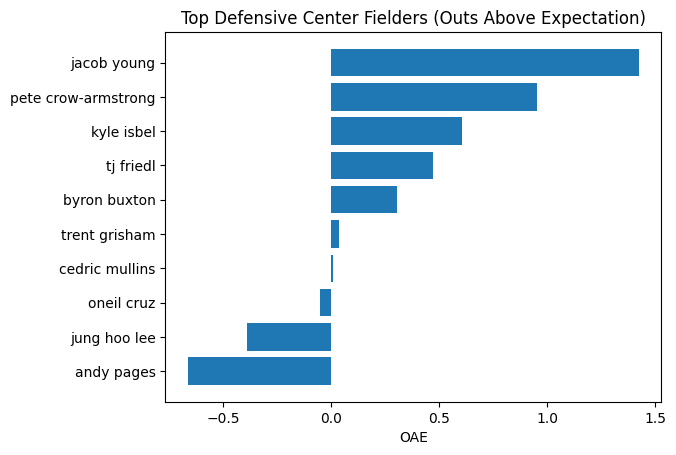

In [45]:
import matplotlib.pyplot as plt

top_players = player_stats.sort_values('OAE', ascending=False).head(10)

plt.figure()
plt.barh(top_players['name'], top_players['OAE'])
plt.title("Top Defensive Center Fielders (Outs Above Expectation)")
plt.xlabel("OAE")
plt.gca().invert_yaxis()
plt.show()



Chart 2: Expected vs Actual

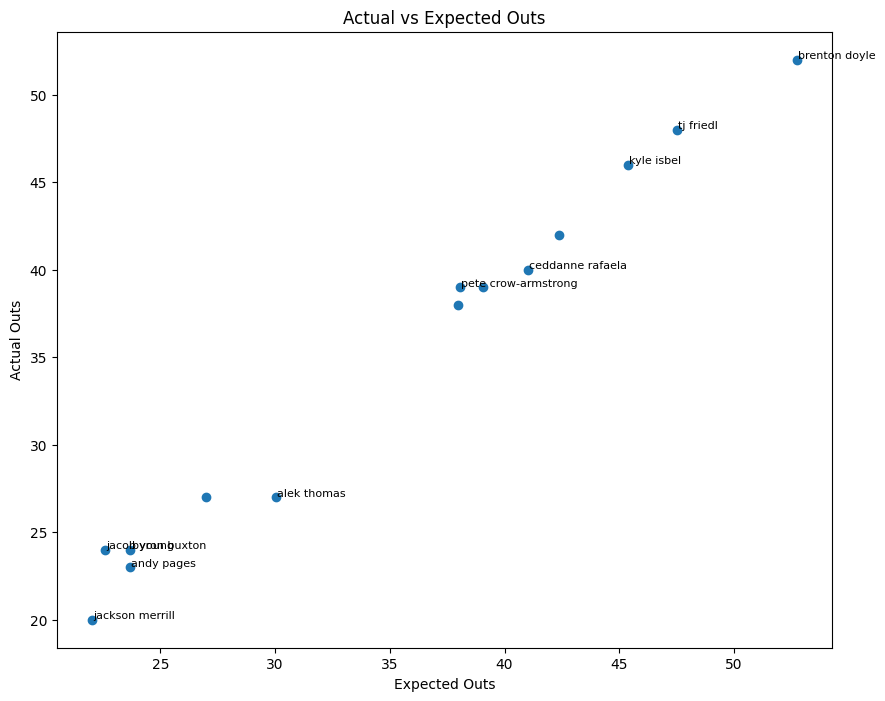

In [44]:
# Actual vs expected
#plt.figure(figsize=(8, 6))
#plt.scatter(player_stats['expected_outs'], player_stats['actual_outs'])
#plt.xlabel("Expected Outs")
#plt.ylabel("Actual Outs")
#plt.title("Actual vs Expected Outs")
#plt.show()

# Revised scatter with labels
label_players = pd.concat([
    player_stats.sort_values('OAE', ascending=False).head(5),
    player_stats.sort_values('OAE', ascending=True).head(5)
]).drop_duplicates()

plt.figure(figsize=(10, 8))
plt.scatter(player_stats['expected_outs'], player_stats['actual_outs'])

for _, row in label_players.iterrows():
    plt.text(
        row['expected_outs'] + 0.05,
        row['actual_outs'] + 0.05,
        row['name'],
        fontsize=8
    )

plt.xlabel("Expected Outs")
plt.ylabel("Actual Outs")
plt.title("Actual vs Expected Outs")
plt.show()